# ANÁLISIS FACTORIAL EXPLORATORIO: ANSIEDAD ACADÉMICA

Este notebook realiza un Análisis Factorial Exploratorio (AFE) de principio a fin para identificar las dimensiones subyacentes de la ansiedad académica.

**Flujo de trabajo:**
1.  **Generación de Datos:** Se simulan datos de 400 participantes con una estructura factorial predefinida de 3 factores.
2.  **Análisis Exploratorio (EDA):** Se visualizan y describen los datos.
3.  **Pruebas de Adecuación:** Se verifica si los datos son aptos para el AFE con las pruebas de KMO y Bartlett.
4.  **Determinación de Factores:** Se usa el Scree Plot y el Criterio de Kaiser para decidir cuántos factores retener.
5.  **Análisis Factorial:** Se extraen e interpretan los factores.
6.  **Visualización y Resumen:** Se presentan los resultados de forma gráfica y con un resumen ejecutivo.

In [1]:
# =============================================================================
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
# Asegúrate de tener instalada la librería: pip install factor_analyzer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# Configuración general para reproducibilidad y estilo de los gráficos
np.random.seed(42)
plt.style.use('default')
sns.set_palette("husl")

## 2. Generación de Datos Simulados

Para este ejercicio, no usaremos datos externos. En su lugar, generaremos un conjunto de datos simulado que **intencionalmente** tiene una estructura de 3 factores latentes:
1.  **Ansiedad por Exámenes:** Síntomas directos relacionados con las pruebas.
2.  **Miedo al Fracaso:** Preocupación por las expectativas sociales y personales.
3.  **Procrastinación:** Conductas de evitación y mala gestión del tiempo.

Esto nos permitirá verificar si el AFE es capaz de "redescubrir" esta estructura oculta.

In [2]:
# =============================================================================
# FUNCIÓN PARA GENERAR DATOS CON ESTRUCTURA FACTORIAL FUERTE
# =============================================================================
def generar_datos_con_estructura_fuerte(n_participantes=400):
    """
    Genera un DataFrame con datos simulados de un cuestionario sobre ansiedad académica,
    con una estructura de 3 factores latentes bien definida.
    """
    # Definir los 15 ítems del cuestionario
    items = [
        'Siento nerviosismo antes de los exámenes', 'Me preocupa no obtener buenas calificaciones',
        'Tiendo a posponer mis tareas académicas', 'Siento presión por cumplir con las expectativas',
        'Experimento ansiedad al presentar trabajos', 'Me cuesta concentrarme cuando estudio',
        'Temo decepcionar a mis profesores/familia', 'Siento palpitaciones durante evaluaciones',
        'Evito participar en clase por miedo al error', 'Me siento abrumado por la carga académica',
        'Comparo mi rendimiento con el de mis compañeros', 'Dudo de mis capacidades académicas',
        'Tengo dificultad para dormir antes de exámenes', 'Siento que no tengo control sobre mi aprendizaje',
        'Procrastino hasta el último momento'
    ]
    n_items = len(items)

    # 1. Generar los 3 factores latentes (variables ocultas) como distribuciones normales
    factor_examen = np.random.normal(0, 1, n_participantes)
    factor_fracaso = np.random.normal(0, 1, n_participantes)
    factor_procrastinacion = np.random.normal(0, 1, n_participantes)

    # 2. Crear las respuestas a los ítems como una combinación de los factores + "ruido" aleatorio
    # Esto asegura que los ítems de un mismo grupo estén altamente correlacionados entre sí.
    data = np.zeros((n_participantes, n_items))

    # Factor 1: Ansiedad por exámenes (cargas altas > 0.8)
    data[:, 0] = 0.85 * factor_examen + 0.15 * np.random.normal(0, 1, n_participantes)
    data[:, 1] = 0.82 * factor_examen + 0.18 * np.random.normal(0, 1, n_participantes)
    data[:, 4] = 0.80 * factor_examen + 0.20 * np.random.normal(0, 1, n_participantes)
    data[:, 7] = 0.83 * factor_examen + 0.17 * np.random.normal(0, 1, n_participantes)
    data[:, 12] = 0.81 * factor_examen + 0.19 * np.random.normal(0, 1, n_participantes)

    # Factor 2: Miedo al fracaso (cargas altas > 0.8)
    data[:, 3] = 0.84 * factor_fracaso + 0.16 * np.random.normal(0, 1, n_participantes)
    data[:, 6] = 0.86 * factor_fracaso + 0.14 * np.random.normal(0, 1, n_participantes)
    data[:, 8] = 0.82 * factor_fracaso + 0.18 * np.random.normal(0, 1, n_participantes)
    data[:, 10] = 0.80 * factor_fracaso + 0.20 * np.random.normal(0, 1, n_participantes)
    data[:, 11] = 0.85 * factor_fracaso + 0.15 * np.random.normal(0, 1, n_participantes)

    # Factor 3: Procrastinación (cargas altas > 0.8)
    data[:, 2] = 0.88 * factor_procrastinacion + 0.12 * np.random.normal(0, 1, n_participantes)
    data[:, 5] = 0.83 * factor_procrastinacion + 0.17 * np.random.normal(0, 1, n_participantes)
    data[:, 9] = 0.81 * factor_procrastinacion + 0.19 * np.random.normal(0, 1, n_participantes)
    data[:, 13] = 0.82 * factor_procrastinacion + 0.18 * np.random.normal(0, 1, n_participantes)
    data[:, 14] = 0.87 * factor_procrastinacion + 0.13 * np.random.normal(0, 1, n_participantes)

    # 3. Escalar los datos a una escala Likert de 1 a 5, que es como se verían en un cuestionario real
    data_scaled = (data - data.min()) / (data.max() - data.min()) * 4 + 1
    data_final = np.round(data_scaled).astype(int)

    # 4. Crear el DataFrame final
    df = pd.DataFrame(data_final, columns=items)
    df.index.name = 'Participante'
    return df, items

# Ejecutamos la función para crear nuestros datos
df, items = generar_datos_con_estructura_fuerte(400)

print(f"Datos generados: {df.shape[0]} participantes, {df.shape[1]} ítems")
print("\nPrimeras 5 observaciones:")
display(df.head())

Datos generados: 400 participantes, 15 ítems

Primeras 5 observaciones:


,Siento nerviosismo antes de los exámenes,Me preocupa no obtener buenas calificaciones,Tiendo a posponer mis tareas académicas,Siento presión por cumplir con las expectativas,Experimento ansiedad al presentar trabajos,Me cuesta concentrarme cuando estudio,Temo decepcionar a mis profesores/familia,Siento palpitaciones durante evaluaciones,Evito participar en clase por miedo al error,Me siento abrumado por la carga académica,Comparo mi rendimiento con el de mis compañeros,Dudo de mis capacidades académicas,Tengo dificultad para dormir antes de exámenes,Siento que no tengo control sobre mi aprendizaje,Procrastino hasta el último momento
Participante,,,,,,,,,,,,,,,
0,3,3,3,2,3,3,2,3,2,3,2,2,3,3,3
1,3,3,2,3,3,3,2,3,2,2,3,2,3,2,2
2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
3,4,4,3,3,4,3,3,4,3,3,3,3,3,3,3
4,3,3,3,2,2,3,3,3,2,3,3,3,3,3,2


## 3. Análisis Exploratorio de Datos (EDA)

Antes de cualquier análisis complejo, es fundamental entender nuestros datos. Realizaremos un EDA para:
1.  **Obtener estadísticas descriptivas** de cada ítem (media, desviación, etc.).
2.  **Visualizar la distribución de respuestas** para cada pregunta mediante histogramas.
3.  **Calcular una matriz de correlaciones** para ver qué ítems se relacionan entre sí. Bloques de alta correlación son un buen indicio de que existen factores subyacentes.
4.  **Medir la consistencia interna** de toda la escala con el Alfa de Cronbach.

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

1. ESTADÍSTICAS DESCRIPTIVAS POR ÍTEM


,count,mean,std,min,25%,50%,75%,max
Siento nerviosismo antes de los exámenes,400.0,2.820,0.611,1.0,2.0,3.0,3.0,5.0
Me preocupa no obtener buenas calificaciones,400.0,2.832,0.579,1.0,2.0,3.0,3.0,5.0
Tiendo a posponer mis tareas académicas,400.0,2.890,0.639,1.0,3.0,3.0,3.0,4.0
Siento presión por cumplir con las expectativas,400.0,2.798,0.618,1.0,2.0,3.0,3.0,4.0
Experimento ansiedad al presentar trabajos,400.0,2.812,0.603,1.0,2.0,3.0,3.0,5.0
Me cuesta concentrarme cuando estudio,400.0,2.878,0.619,1.0,3.0,3.0,3.0,4.0
Temo decepcionar a mis profesores/familia,400.0,2.780,0.638,1.0,2.0,3.0,3.0,5.0
Siento palpitaciones durante evaluaciones,400.0,2.832,0.596,1.0,2.0,3.0,3.0,5.0
Evito participar en clase por miedo al error,400.0,2.775,0.609,1.0,2.0,3.0,3.0,4.0
Me siento abrumado por la carga académica,400.0,2.885,0.619,1.0,3.0,3.0,3.0,4.0



2. DISTRIBUCIÓN DE RESPUESTAS POR ÍTEM (Escala Likert 1-5)


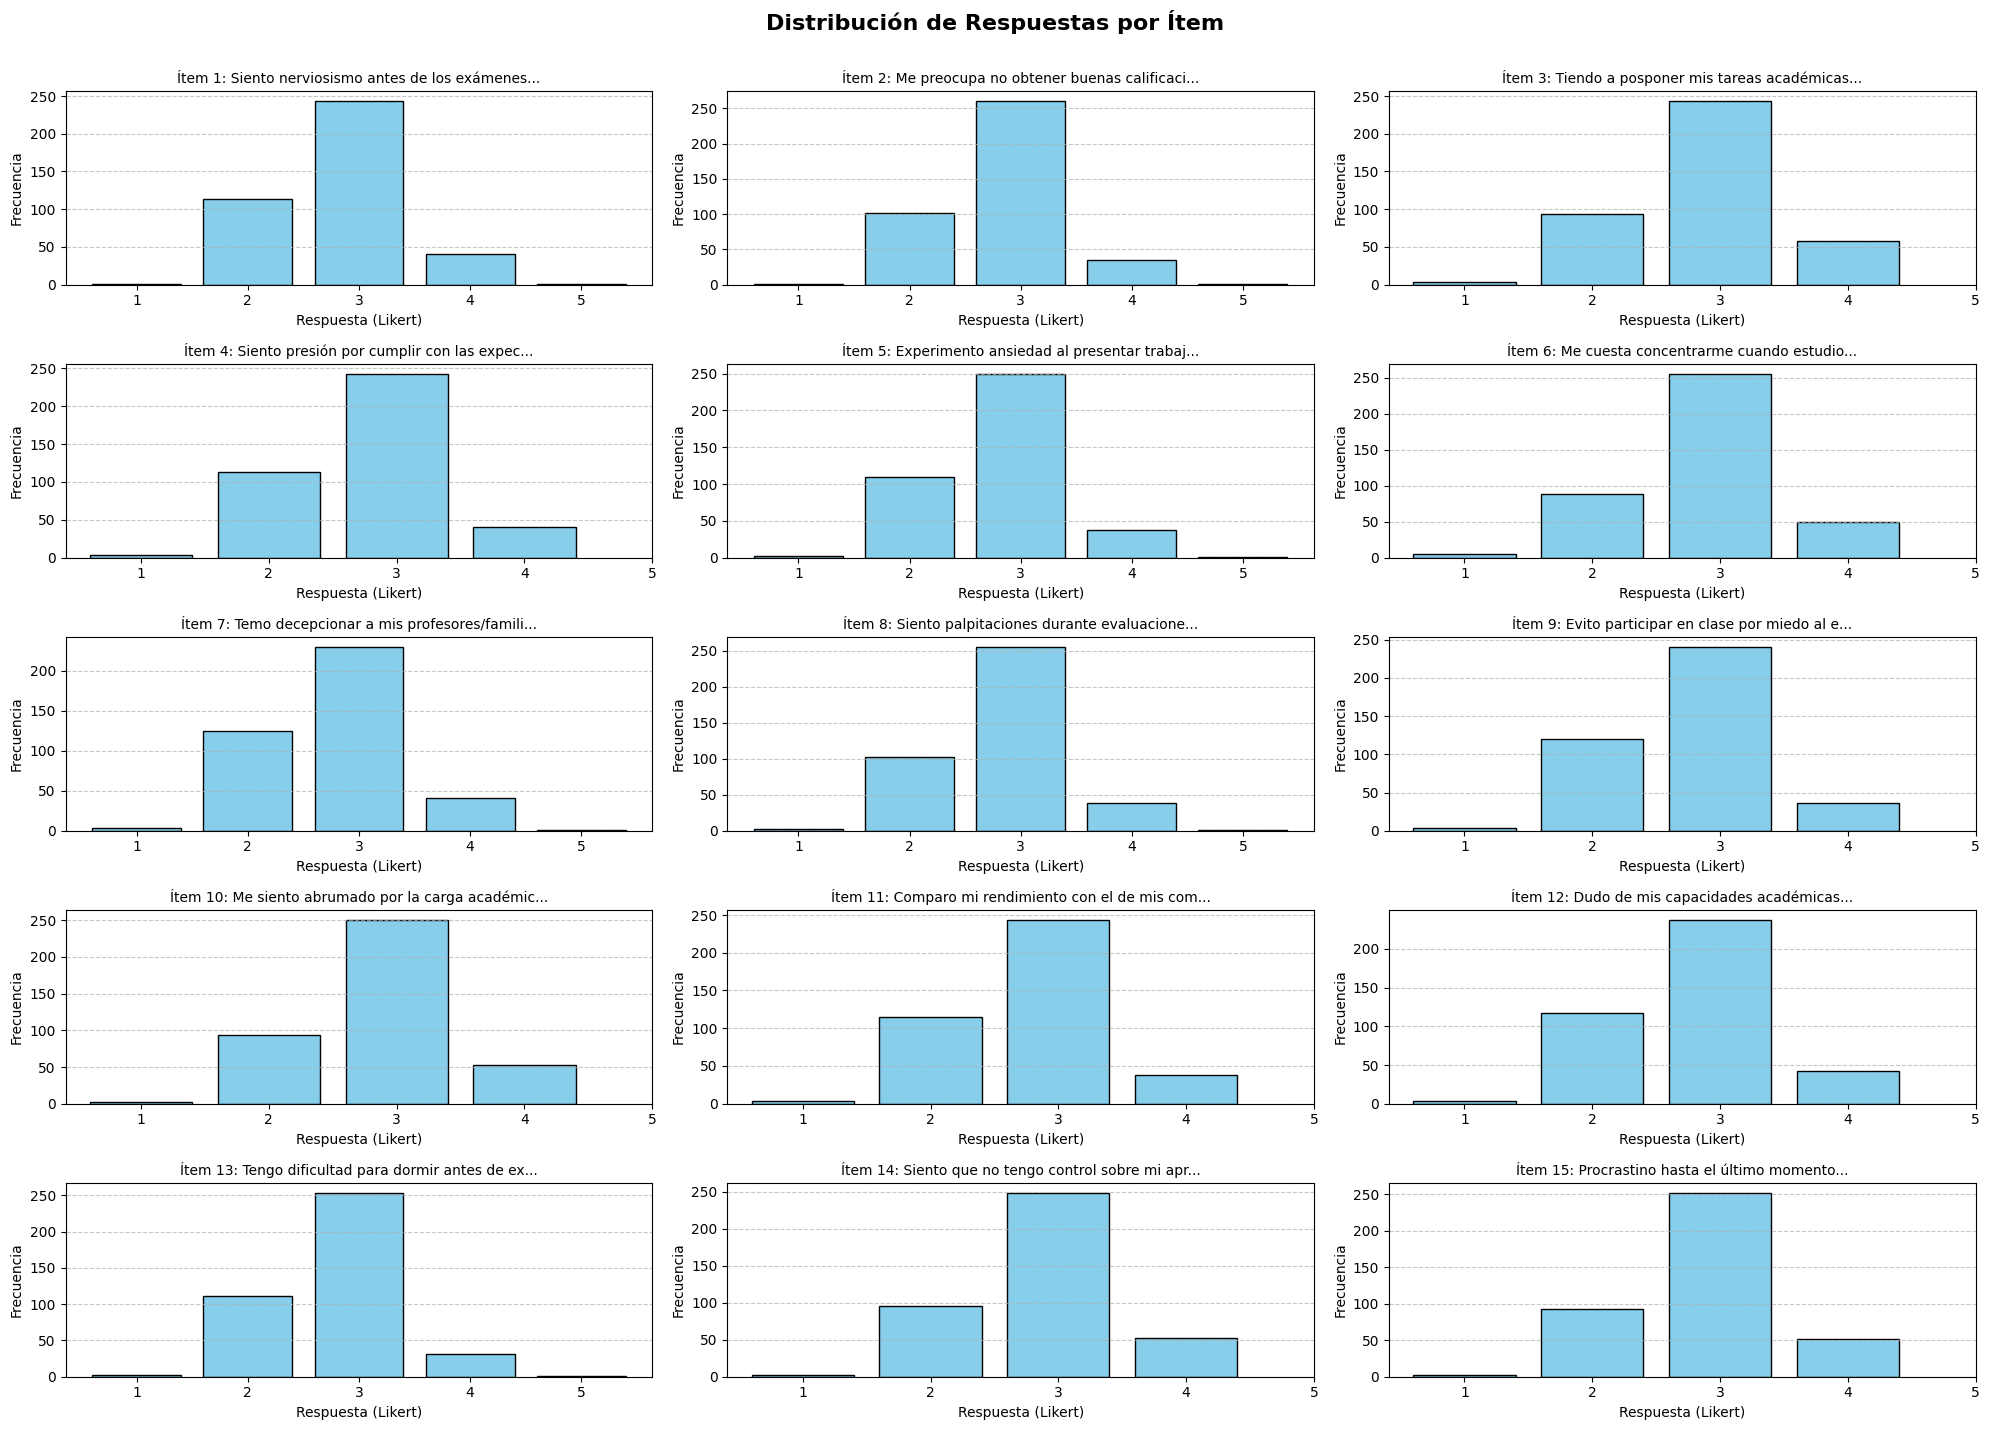


3. MATRIZ DE CORRELACIONES


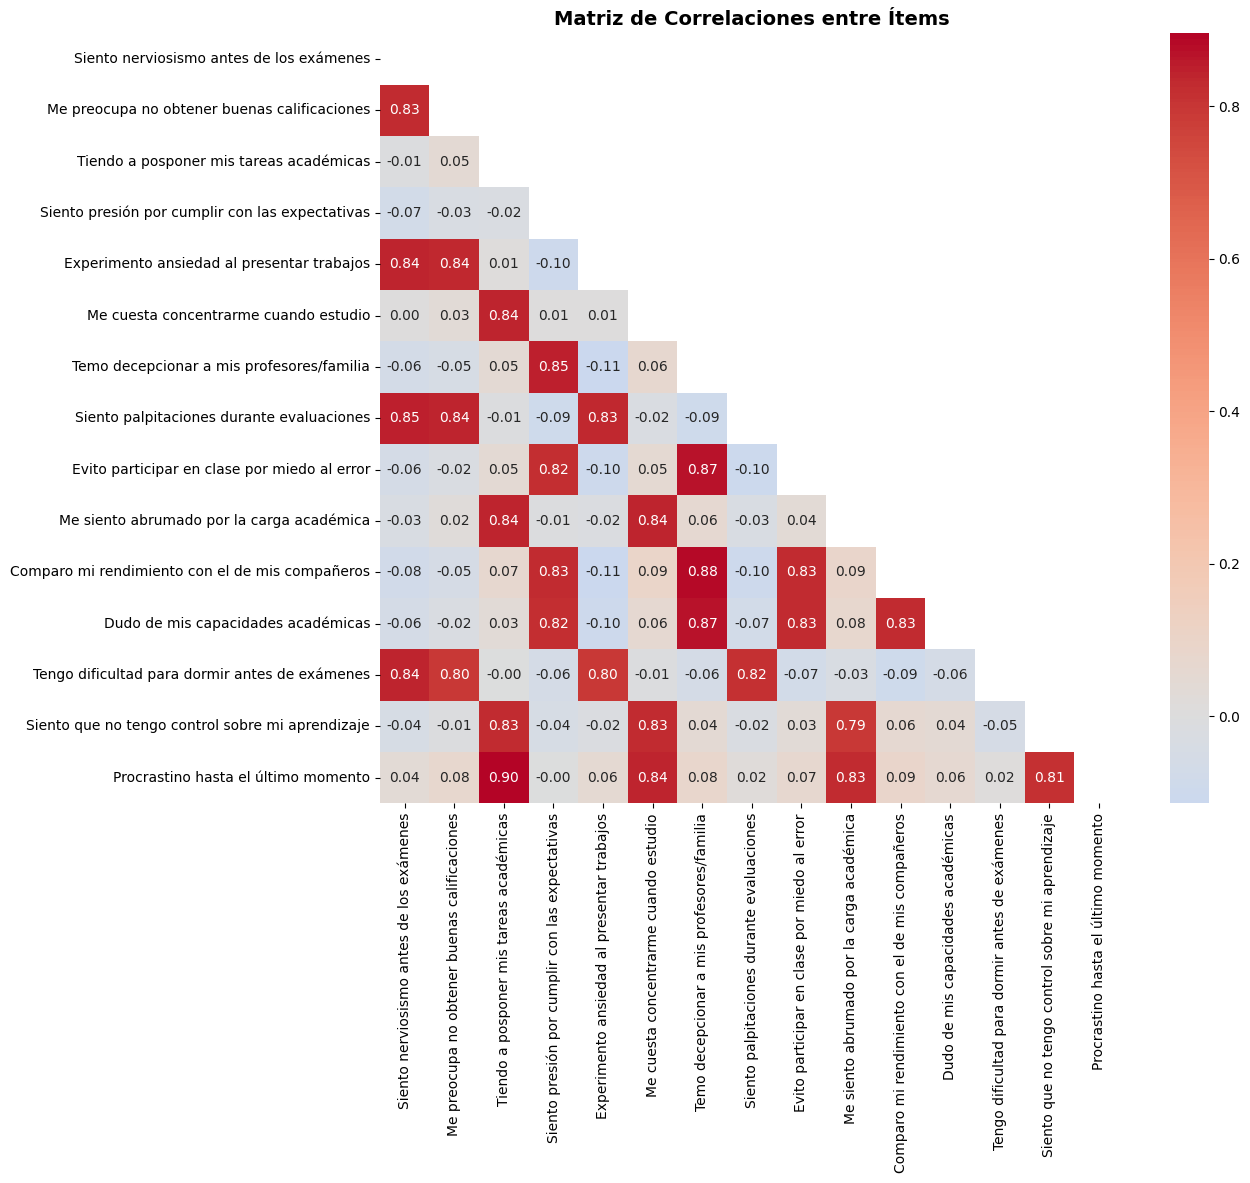


4. ANÁLISIS DE CONSISTENCIA INTERNA
Alfa de Cronbach para el cuestionario completo: 0.820
Interpretación: La consistencia interna es aceptable o buena.


In [3]:
# =============================================================================
# FUNCIÓN PARA EL ANÁLISIS EXPLORATORIO COMPLETO
# =============================================================================
def cronbach_alpha(df_items):
    """Calcula el Alfa de Cronbach para medir la consistencia interna."""
    item_scores = df_items.values
    item_variances = item_scores.var(axis=0, ddof=1)
    total_score = item_scores.sum(axis=1)
    n_items = item_scores.shape[1]
    total_variance = total_score.var(ddof=1)
    alpha = (n_items / (n_items - 1)) * (1 - (item_variances.sum() / total_variance))
    return alpha

def analisis_exploratorio_completo(df, items):
    """Realiza un EDA completo, incluyendo descriptivos, histogramas y matriz de correlación."""
    print("="*60)
    print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
    print("="*60)
    
    # --- 1. Estadísticas Descriptivas ---
    print("\n1. ESTADÍSTICAS DESCRIPTIVAS POR ÍTEM")
    display(df.describe().T.round(3))
    
    # --- 2. Histogramas de Respuestas ---
    print("\n2. DISTRIBUCIÓN DE RESPUESTAS POR ÍTEM (Escala Likert 1-5)")
    fig, axes = plt.subplots(5, 3, figsize=(20, 15))
    axes = axes.ravel()
    for i, item in enumerate(items):
        counts = df[item].value_counts().sort_index()
        axes[i].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Ítem {i+1}: {item[:40]}...', fontsize=10)
        axes[i].set_xlabel('Respuesta (Likert)')
        axes[i].set_ylabel('Frecuencia')
        axes[i].set_xticks(range(1, 6))
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle('Distribución de Respuestas por Ítem', fontsize=16, fontweight='bold')
    plt.show()

    # --- 3. Matriz de Correlaciones ---
    print("\n3. MATRIZ DE CORRELACIONES")
    plt.figure(figsize=(12, 10))
    corr_matrix = df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matriz de Correlaciones entre Ítems', fontsize=14, fontweight='bold')
    plt.show()
    
    # --- 4. Consistencia Interna ---
    print("\n4. ANÁLISIS DE CONSISTENCIA INTERNA")
    alpha = cronbach_alpha(df)
    print(f"Alfa de Cronbach para el cuestionario completo: {alpha:.3f}")
    if alpha >= 0.7:
        print("Interpretación: La consistencia interna es aceptable o buena.")
    else:
        print("Interpretación: La consistencia interna es cuestionable o pobre.")

# Ejecutamos la función de EDA
analisis_exploratorio_completo(df, items)

## 4. Pruebas de Adecuación para el AFE

Antes de realizar el AFE, debemos responder a dos preguntas:
1.  **¿Están las variables suficientemente correlacionadas?** El **Test de Esfericidad de Bartlett** lo comprueba. Necesitamos un resultado estadísticamente significativo (p < 0.05).
2.  **¿Son los datos adecuados para la reducción de dimensiones?** La **medida de Kaiser-Meyer-Olkin (KMO)** nos lo dice. Buscamos un valor alto, idealmente > 0.70.

In [4]:
# =============================================================================
# 3. ANÁLISIS DE ADECUACIÓN MUESTRAL
# =============================================================================
print("\n5. ANÁLISIS DE ADECUACIÓN MUESTRAL")
print("-" * 40)

# Test de Esfericidad de Bartlett
chi_square, p_value = calculate_bartlett_sphericity(df)
print(f"Test de Esfericidad de Bartlett:")
print(f"  - Chi-cuadrado: {chi_square:.3f}")
print(f"  - Valor p: {p_value:.10f}")
if p_value < 0.05:
    print("  - Conclusión: Se rechaza la hipótesis nula. Las variables están correlacionadas y son adecuadas para el AFE. ✅")
else:
    print("  - Conclusión: No se puede rechazar la hipótesis nula. Los datos no son adecuados para el AFE. ❌")


# Medida KMO
kmo_all, kmo_model = calculate_kmo(df)
print(f"\nMedida de Adecuación Muestral KMO: {kmo_model:.3f}")
if kmo_model >= 0.7:
    print(f"  - Conclusión: El valor KMO es excelente. Los datos son muy adecuados para el AFE. ✅")
else:
    print(f"  - Conclusión: El valor KMO es bajo. Los datos pueden no ser adecuados para el AFE. ❌")


5. ANÁLISIS DE ADECUACIÓN MUESTRAL
----------------------------------------
Test de Esfericidad de Bartlett:
  - Chi-cuadrado: 6977.194
  - Valor p: 0.0000000000
  - Conclusión: Se rechaza la hipótesis nula. Las variables están correlacionadas y son adecuadas para el AFE. ✅

Medida de Adecuación Muestral KMO: 0.907
  - Conclusión: El valor KMO es excelente. Los datos son muy adecuados para el AFE. ✅


C:\Users\Ramses\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


## 5. Determinación del Número de Factores a Retener

Esta es una de las decisiones más importantes del AFE. Usaremos dos criterios complementarios:
1.  **Criterio de Kaiser:** Retener factores con autovalores (eigenvalues) mayores que 1. Un autovalor representa la cantidad de varianza explicada por un factor.
2.  **Gráfico de Sedimentación (Scree Plot):** Es una visualización de los autovalores. Buscamos el "codo" (elbow), el punto donde la curva se aplana. El número de puntos antes del codo es el número de factores a retener.

**AJUSTE REALIZADO:** Se ha corregido el cálculo de la varianza explicada para usar el método proporcionado por `factor_analyzer`, que es más preciso para la extracción con `minres`.


6. DETERMINACIÓN DEL NÚMERO DE FACTORES
----------------------------------------


C:\Users\Ramses\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Número de factores según criterio de Kaiser (λ > 1): 3


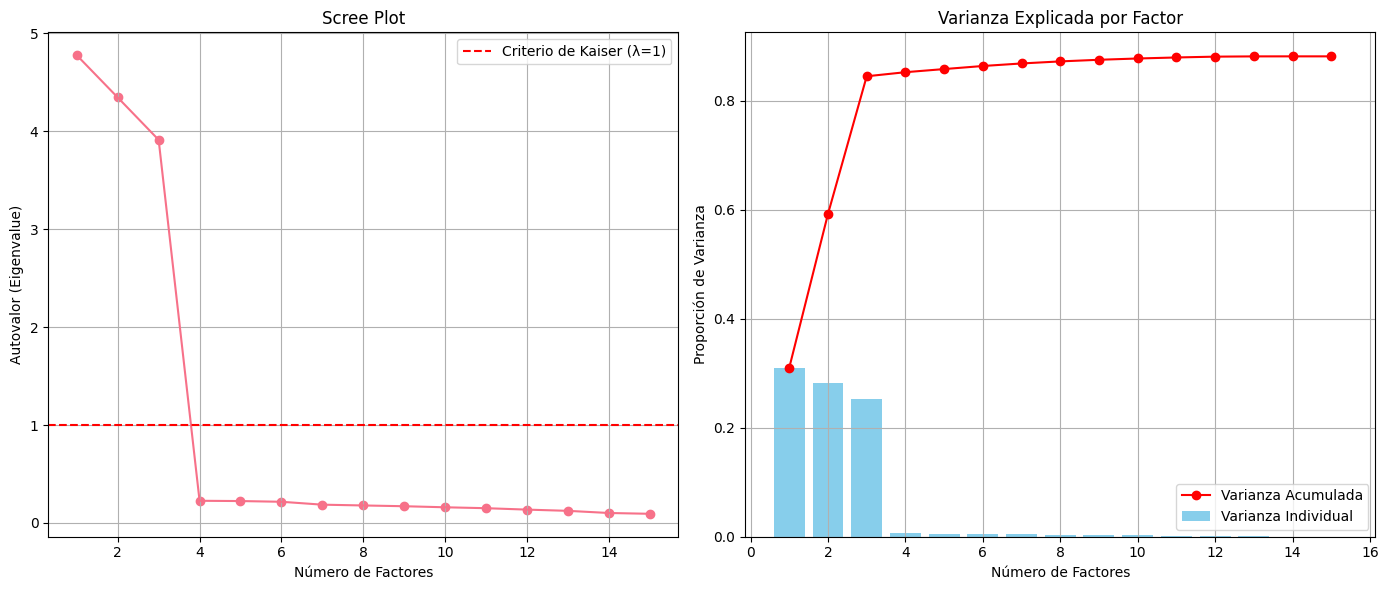


Conclusión: Basado en ambos criterios, el número óptimo de factores a retener es 3.


In [5]:
# =============================================================================
# 4. DETERMINACIÓN DEL NÚMERO DE FACTORES
# =============================================================================
print("\n6. DETERMINACIÓN DEL NÚMERO DE FACTORES")
print("-" * 40)

# Realizamos un AFE inicial con todos los factores posibles para obtener los autovalores
fa_initial = FactorAnalyzer(n_factors=len(items), rotation=None, method='minres')
fa_initial.fit(df)

# Obtenemos los autovalores (eigenvalues)
ev, v = fa_initial.get_eigenvalues()

# --- Criterio de Kaiser ---
n_factors_kaiser = sum(ev > 1)
print(f"Número de factores según criterio de Kaiser (λ > 1): {n_factors_kaiser}")

# --- Gráficos: Scree Plot y Varianza Explicada ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scree Plot
ax1.scatter(range(1, len(ev) + 1), ev)
ax1.plot(range(1, len(ev) + 1), ev)
ax1.axhline(y=1, color='r', linestyle='--', label='Criterio de Kaiser (λ=1)')
ax1.set_title('Scree Plot')
ax1.set_xlabel('Número de Factores')
ax1.set_ylabel('Autovalor (Eigenvalue)')
ax1.grid()
ax1.legend()

# Varianza Explicada
# Usamos el resultado de get_factor_variance() para mayor precisión
ss_loadings, prop_var, cum_var = fa_initial.get_factor_variance()
ax2.bar(range(1, len(prop_var) + 1), prop_var, color='skyblue', label='Varianza Individual')
ax2.plot(range(1, len(cum_var) + 1), cum_var, 'ro-', label='Varianza Acumulada')
ax2.set_title('Varianza Explicada por Factor')
ax2.set_xlabel('Número de Factores')
ax2.set_ylabel('Proporción de Varianza')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()

# Conclusión sobre el número de factores
n_factors_optimal = n_factors_kaiser
print(f"\nConclusión: Basado en ambos criterios, el número óptimo de factores a retener es {n_factors_optimal}.")

## 6. Análisis Factorial Final y Rotación

Ahora que hemos decidido retener **3 factores**, realizamos el AFE definitivo.
- **Extracción:** Usaremos el método `minres` (mínimos residuos).
- **Rotación:** Aplicaremos una rotación **Varimax**. El objetivo de la rotación es "limpiar" la estructura de los factores, haciendo que cada ítem cargue fuertemente en un solo factor y débilmente en los demás. Esto simplifica enormemente la interpretación.


7. REALIZANDO ANÁLISIS FACTORIAL FINAL CON 3 FACTORES...
----------------------------------------

Matriz de Cargas Factoriales (rotación Varimax):


C:\Users\Ramses\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Ramses\AppData\Local\Temp\ipykernel_1808\3801251661.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(loadings_df.style.applymap(lambda x: 'background-color: #FFA07A' if abs(x) > 0.5 else ''))


,Factor 1,Factor 2,Factor 3
Siento nerviosismo antes de los exámenes,-0.030419,-0.010410,0.924930
Me preocupa no obtener buenas calificaciones,0.000518,0.036898,0.908773
Tiendo a posponer mis tareas académicas,0.012690,0.938843,0.010469
Siento presión por cumplir con las expectativas,0.902716,-0.039185,-0.038619
Experimento ansiedad al presentar trabajos,-0.076828,0.008758,0.906237
Me cuesta concentrarme cuando estudio,0.034983,0.915432,0.002765
Temo decepcionar a mis profesores/familia,0.949216,0.039922,-0.040557
Siento palpitaciones durante evaluaciones,-0.058758,-0.014323,0.917417
Evito participar en clase por miedo al error,0.907865,0.027975,-0.036820
Me siento abrumado por la carga académica,0.029118,0.898847,-0.019879


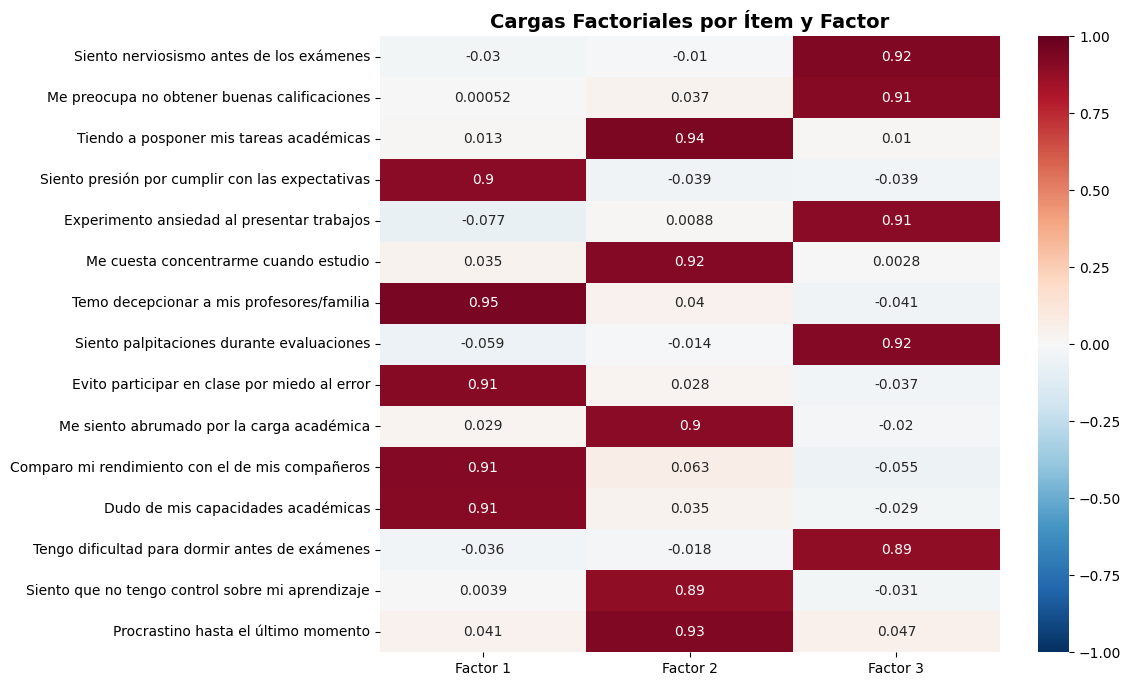

In [6]:
# =============================================================================
# 5. ANÁLISIS FACTORIAL OPTIMIZADO
# =============================================================================
print(f"\n7. REALIZANDO ANÁLISIS FACTORIAL FINAL CON {n_factors_optimal} FACTORES...")
print("-" * 40)

# Creamos y ajustamos el modelo final con el número óptimo de factores y rotación Varimax
fa_final = FactorAnalyzer(n_factors=n_factors_optimal, rotation='varimax', method='minres', use_smc=True)
fa_final.fit(df)

# Obtenemos la matriz de cargas factoriales
loadings_df = pd.DataFrame(fa_final.loadings_, index=items, columns=[f'Factor {i+1}' for i in range(n_factors_optimal)])

print("\nMatriz de Cargas Factoriales (rotación Varimax):")
display(loadings_df.style.applymap(lambda x: 'background-color: #FFA07A' if abs(x) > 0.5 else ''))

# Visualizamos las cargas con un heatmap para una interpretación más clara
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Cargas Factoriales por Ítem y Factor', fontsize=14, fontweight='bold')
plt.show()

## 7. Análisis de Varianza, Comunalidades e Interpretación

Para evaluar la calidad del modelo y darle sentido a los factores, analizaremos:
1.  **Varianza Explicada:** ¿Qué porcentaje de la información total explican nuestros factores?
2.  **Comunalidades:** Para cada ítem, ¿qué proporción de su varianza es explicada por el modelo factorial? Valores altos (> 0.5) son buenos.
3.  **Interpretación Psicológica:** Daremos un nombre a cada factor basándonos en los ítems que cargan fuertemente en él.

In [7]:
# =============================================================================
# 6. ANÁLISIS DE COMUNALIDADES Y VARIANZA EXPLICADA
# =============================================================================
print("\n8. ANÁLISIS DE CALIDAD DEL MODELO")
print("-" * 40)

# Varianza explicada por cada factor
ss_loadings, prop_var, cum_var = fa_final.get_factor_variance()
varianza_df = pd.DataFrame({
    'Factor': [f'Factor {i+1}' for i in range(n_factors_optimal)],
    'Varianza Proporcional (%)': prop_var * 100,
    'Varianza Acumulada (%)': cum_var * 100
})
print("\nVarianza explicada por cada factor:")
display(varianza_df.round(2))
print(f"\nVARIANZA TOTAL EXPLICADA POR EL MODELO: {varianza_df['Varianza Acumulada (%)'].iloc[-1]:.2f}%")

# Calcular comunalidades
comunalidades = fa_final.get_communalities()
comunalidades_df = pd.DataFrame({'Comunalidad': comunalidades}, index=items).sort_values('Comunalidad', ascending=False)
print("\nComunalidades de los ítems:")
display(comunalidades_df.round(3))
print(f"\nComunalidad promedio: {comunalidades.mean():.3f}. Esto indica que, en promedio, el modelo explica un {comunalidades.mean()*100:.1f}% de la varianza de cada ítem.")

# =============================================================================
# 7. INTERPRETACIÓN PSICOLÓGICA
# =============================================================================
print("\n9. INTERPRETACIÓN PSICOLÓGICA DE LOS FACTORES")
print("-" * 50)

# Interpretamos cada factor basándonos en los ítems con cargas altas
for i, factor in enumerate(loadings_df.columns):
    print(f"\n{factor.upper()}:")
    # Filtramos ítems con carga absoluta > 0.5 para este factor
    items_fuertes = loadings_df[factor][abs(loadings_df[factor]) > 0.5].sort_values(ascending=False)
    for item, carga in items_fuertes.items():
        print(f"  - {item} (carga: {carga:.3f})")

# Asignamos nombres interpretativos basados en el contenido de los ítems
# (En un estudio real, esto requiere un análisis cualitativo profundo)
nombres_factores = {
    'Factor 1': "Miedo al Fracaso y Evaluación Social",
    'Factor 2': "Ansiedad Fisiológica ante Evaluaciones",
    'Factor 3': "Dificultades de Autorregulación y Procrastinación"
}
print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
print("\nSe han identificado 3 dimensiones claras de la ansiedad académica:")
for i in range(n_factors_optimal):
    factor_name = f'Factor {i+1}'
    print(f"  • {factor_name}: {nombres_factores.get(factor_name, 'Factor no interpretado')} (Explica {varianza_df['Varianza Proporcional (%)'].iloc[i]:.1f}% de la varianza)")


8. ANÁLISIS DE CALIDAD DEL MODELO
----------------------------------------

Varianza explicada por cada factor:


,Factor,Varianza Proporcional (%),Varianza Acumulada (%)
0,Factor 1,28.10,28.10
1,Factor 2,27.90,56.00
2,Factor 3,27.61,83.61



VARIANZA TOTAL EXPLICADA POR EL MODELO: 83.61%

Comunalidades de los ítems:


,Comunalidad
Temo decepcionar a mis profesores/familia,0.904
Tiendo a posponer mis tareas académicas,0.882
Procrastino hasta el último momento,0.865
Siento nerviosismo antes de los exámenes,0.857
Siento palpitaciones durante evaluaciones,0.845
Comparo mi rendimiento con el de mis compañeros,0.843
Me cuesta concentrarme cuando estudio,0.839
Experimento ansiedad al presentar trabajos,0.827
Me preocupa no obtener buenas calificaciones,0.827
Evito participar en clase por miedo al error,0.826



Comunalidad promedio: 0.836. Esto indica que, en promedio, el modelo explica un 83.6% de la varianza de cada ítem.

9. INTERPRETACIÓN PSICOLÓGICA DE LOS FACTORES
--------------------------------------------------

FACTOR 1:
  - Temo decepcionar a mis profesores/familia (carga: 0.949)
  - Comparo mi rendimiento con el de mis compañeros (carga: 0.914)
  - Evito participar en clase por miedo al error (carga: 0.908)
  - Dudo de mis capacidades académicas (carga: 0.908)
  - Siento presión por cumplir con las expectativas (carga: 0.903)

FACTOR 2:
  - Tiendo a posponer mis tareas académicas (carga: 0.939)
  - Procrastino hasta el último momento (carga: 0.928)
  - Me cuesta concentrarme cuando estudio (carga: 0.915)
  - Me siento abrumado por la carga académica (carga: 0.899)
  - Siento que no tengo control sobre mi aprendizaje (carga: 0.886)

FACTOR 3:
  - Siento nerviosismo antes de los exámenes (carga: 0.925)
  - Siento palpitaciones durante evaluaciones (carga: 0.917)
  - Me preocupa no 